In [1]:
import MetaArray
import os, glob
import numpy as np
import matplotlib.pyplot as plt
import scipy.ndimage

In [2]:
yaw_angle = 1.6  # degrees, from manipulator calibration
data_path = 'template_data/'
pip_data_path = data_path + 'pipette_data/'
noise_data_path = data_path + 'background_data/'
pip_data_files = sorted(glob.glob(pip_data_path + '*/*.ma'))
noise_data_files = sorted(glob.glob(noise_data_path + '*/*.ma'))

In [3]:
pips = []
for i in range(0, len(pip_data_files), 2):
    print(f"Processing {pip_data_files[i]}")
    # load pipette and background data
    pip_ma = MetaArray.MetaArray(file=pip_data_files[i])
    bg_ma = MetaArray.MetaArray(file=pip_data_files[i+1])
    # subtract background
    pip = pip_ma.asarray().astype(float) - bg_ma.asarray().astype(float)
    # rotate
    pip = scipy.ndimage.rotate(pip, axes=(1, 2), angle=-90-yaw_angle)
    # pip = scipy.ndimage.rotate(pip[110:111], axes=(1, 2), angle=-90-yaw_angle)
    # crop to remove rotation artifacts
    pip = pip[:, 30:-30, 30:-30]
    pips.append(pip)

Processing template_data/pipette_data/ImageSequence_006/image_000.ma
Processing template_data/pipette_data/ImageSequence_009/image_000.ma
Processing template_data/pipette_data/ImageSequence_012/image_000.ma
Processing template_data/pipette_data/ImageSequence_015/image_000.ma
Processing template_data/pipette_data/ImageSequence_018/image_000.ma
Processing template_data/pipette_data/ImageSequence_021/image_000.ma


In [4]:
z_step_size = np.diff(pip_ma.xvals(0)).mean()
z_step_size

-1.0000000000001327e-06

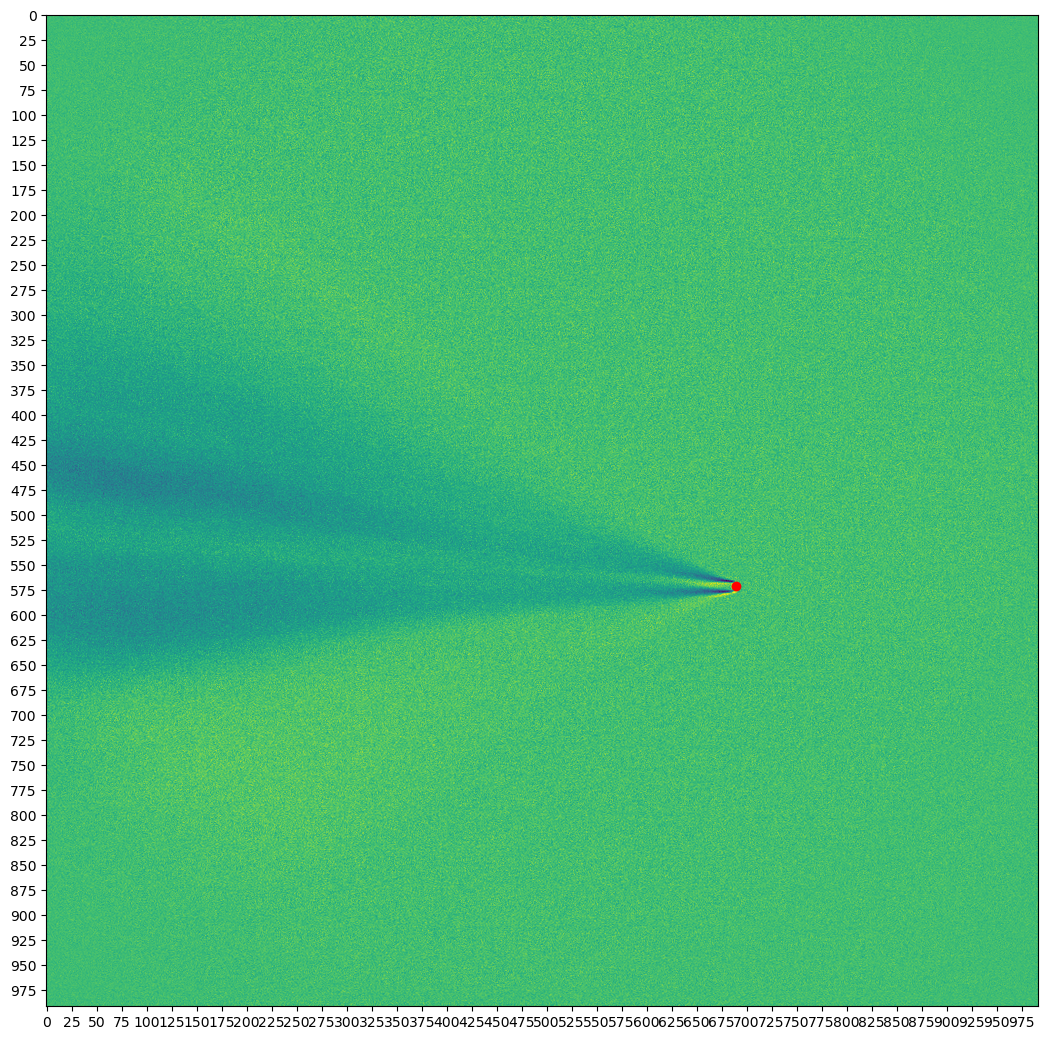

In [5]:
# manually extracted tip positions
tips = [
    (110, 476, 712),
    (155, 526, 691),
    (152, 571, 689),
    (155, 479, 680),
    (155, 478, 664),
    (154, 478, 664),
]

# which template to display below
i = 2

fig, ax = plt.subplots(figsize=(12.88, 12.88))
tip = tips[i]
img = pips[i][tip[0]]
ax.imshow(img)
ax.scatter(tip[2], tip[1], color='r')
spacing = 25
ax.set_xticks(range(0, img.shape[1], spacing));
ax.set_yticks(range(0, img.shape[0], spacing));

Processing 0
Processing 1
Processing 2
Processing 3
Processing 4
Processing 5


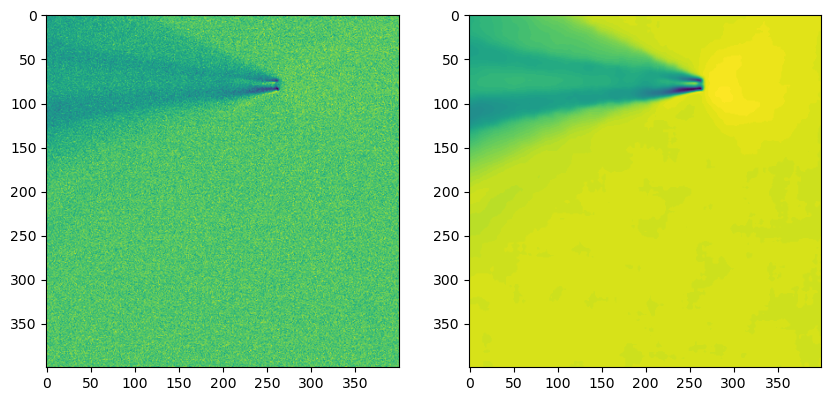

In [6]:
# remove noise

import cv2 as cv

def denoise(img):
    img_min = img.min()
    img_max = img.max()
    scale = 255 / (img_max - img_min)
    normed_img = (img - img_min) * scale
    gauss_filtered = scipy.ndimage.gaussian_filter(normed_img, (1, 1, 1))
    byte_img = np.clip(gauss_filtered, 0, 255).astype(np.uint8)

    denoised = []
    for i in range(byte_img.shape[0]):
        radius = min(i, byte_img.shape[0] - i - 1, 2)
        denoised.append(cv.fastNlMeansDenoisingMulti(byte_img, i, 
            temporalWindowSize=radius*2+1, h=7, templateWindowSize=7, searchWindowSize=21))
    return np.stack(denoised)


denoised = []
for i, pip in enumerate(pips):
    print(f"Processing {i}")
    denoised.append(denoise(pip))

fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].imshow(pips[5][155, 400:800, 400:800])
ax[1].imshow(denoised[5][155, 400:800, 400:800])


In [7]:
masks = []
n_pips = len(pips)
for i in range(n_pips):
    # apply mask to fade out
    def gradient(row, col):
        tip = tips[i]
        maxr = min(tip[1], tip[2])
        r = ((row - tip[1])**2 + (col - tip[2])**2) ** 0.5
        return np.clip((maxr - r) / (4 * maxr), 0, 1)
            
    mask = np.fromfunction(gradient, shape=pips[i].shape[1:])
    masks.append(mask)

In [8]:
templates = []
template_pos = []
for i in range(n_pips):
    tip_pos = list(tips[i])
    bg = np.median(denoised[i])
    templ = masks[i][np.newaxis, ...] * (denoised[i] - bg)
    r = min(tip_pos[1], tip_pos[2])
    # crop right/bottom
    templ = templ[:tip_pos[0]+r, :tip_pos[1]+r]
    # crop top
    if tip_pos[1] > r:
        dif = tip_pos[1] - r
        templ = templ[:, dif:, :]
        tip_pos[1] -= dif
    # crop left
    if tip_pos[2] > r:
        dif = tip_pos[2] - r
        templ = templ[:, :, dif:]
        tip_pos[2] -= dif

    # normalize and convert
    templ /= np.abs(templ).max()
    templ = templ.astype('float32')
    # templ -= templ.min()
    # templ *= 255. / templ.max()
    # templ = templ.astype('ubyte')
    
    templates.append(templ)
    template_pos.append(np.array(tip_pos))
    


In [9]:
# save templates
for i,template in enumerate(templates):
    z_um = 1e6 * (template_pos[i][0] - np.arange(template.shape[0])) * z_step_size
    np.savez_compressed(
        data_path + f'template_{i:03d}.npz',
        image_data=template,
        pipette_pos=template_pos[i][1:],
        z_um=z_um,
    ) 

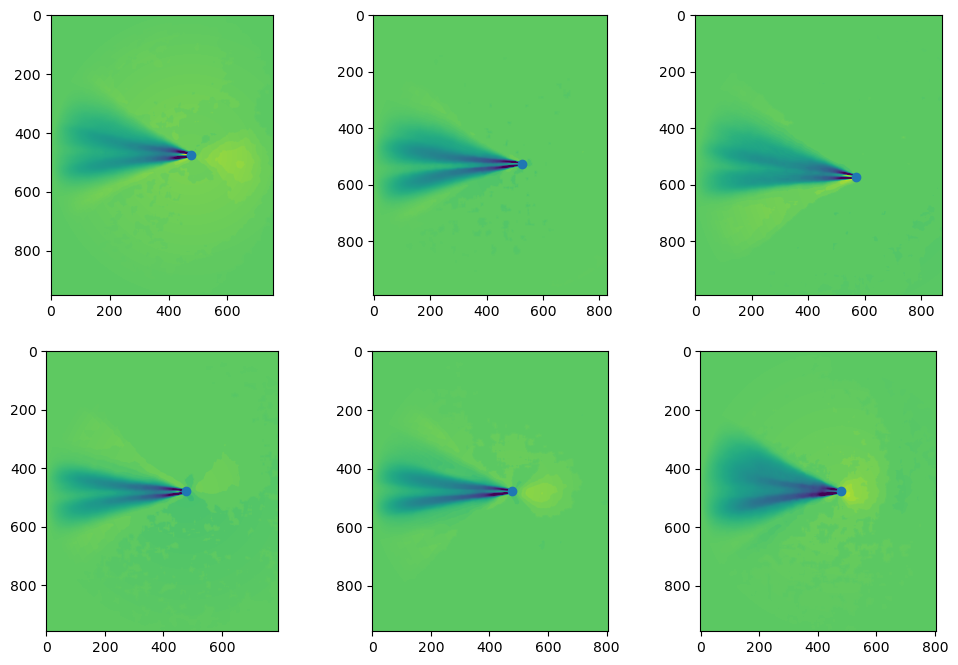

In [10]:
fig, ax = plt.subplots(2, 3, figsize=(12, 8))
for i in range(n_pips):
    tip_pos = template_pos[i]
    ax.flatten()[i].imshow(templates[i][tip_pos[0]], clim=(-.3, .1))
    ax.flatten()[i].scatter(tip_pos[2], tip_pos[1])